____
____
<h1 align="center">
<font color=#18453b>
PY Solver for effective potential
</font>
</h1> 


<h4 align="center">
December 2021
</h4>

____
____
This Jupyter notebook provides the capability to obtain rapid solutions of the PY-equation (closure and Ornstein-Zernicke equations) for 3D system.  
The input you will need to have at hand are:  
- Packing fraction $\eta$.

All the length are in unit of the HS diameter.  

The basic physical model is a many-body system of particles interacting through a pair interaction of the form:         
$$ u(r) = + \infty \; \; \; \; \; if \; \; r < 1$$  
$$ u(r) = - log(c_{2Body}(r) + 1) \; \; \; \; \; if \; \; r > 1 .$$ 

The system is:  
$$\gamma(k) = \frac{\rho^* c^2(k)}{1 - \rho^* c(k)},$$  
$$ g(r) = e^{- u(r)} (1 + \gamma(r)).$$ 

This jupyter can be used to compute the PY bridge function that can be exploited using the virial-compressibility route consistency: 
$$b_{PY}(r) = -c(r) -1 - log(-c(r)) \; \; \; \; \; if \; \; r < 1 $$  
$$b_{PY}(r) = g(r) - 1 -log(g(r)) \; \; \; \; \; if \; \; r > 1 . $$

In [107]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("bmh")
plt.rcParams.update({'font.size': 24})

from scipy import fftpack
# %matplotlib inline
# %matplotlib notebook
import seaborn as sns

## Grid Initialization

In [108]:
# run parameters
num_iterations = 400
# r binning
N_bins = 250000
R_max = 25
del_r = R_max/N_bins
delta_rc =  0
# error is minimized when using bin centers
r_array = np.linspace(del_r/2+delta_rc,R_max-del_r/2+delta_rc,N_bins)
pressure_iter = np.zeros(num_iterations)    #Dimensionless Pressure
#In order to compute pressure for hard-core pair potential
idx = (np.abs(r_array - 1)).argmin()
if(r_array[idx]< 1):
    idx = idx+1

# k binning
del_k = np.pi/(N_bins*del_r)
K_max = del_k*N_bins
k_array = np.linspace(del_k/2,K_max-del_k/2,N_bins)

# precompute factors 
fact_r_2_k = 2*np.pi*del_r                 
fact_k_2_r = del_k/(4.*np.pi**2)    
#np.savetxt('r.out',r_array.T)

## Fourier Transform

In [109]:
# f(k) = FT[f(r)]
def FT_r_2_k(input_array):
    from_dst = fact_r_2_k*fftpack.dst(r_array*input_array,type=4)     #Modified
    return from_dst/k_array

# f(r) = IFT[f(k)]
def FT_k_2_r(input_array):
    from_idst = fact_k_2_r*fftpack.idst(k_array*input_array,type=4)   #Modified
    return from_idst/r_array

## Physical Parameters

In [110]:
Filename = 'fourier'  #Initial guess
beta = 0.6 #Mixing parmeters, if equal to 1 there is no mixing
G_dil = 'g_EqGrid_HS_deltar0p0001_Pe1000_IA.out'

eta = 0.45 #Volume packing fraction
dimless_dens = eta * 6 / np.pi  #Dimensionless density
#dimless_dens = 0.825

## Routines

In [111]:
def initial_c_k(k_in):
    if(Filename == 'fourier'):
        return 0*k_in
    else:
        return np.loadtxt(Filename,usecols=(1))
def pot(r_array):
    v_tmp = np.zeros(N_bins)
    g_2body = np.loadtxt(G_dil,usecols=(1))
    j=0
    for i in range(N_bins):
        if(r_array[i]<1 or r_array[i]>10):
            v_tmp[i] = 0
        else:
            v_tmp[i] = -np.log( g_2body[j] )
            j = j + 1
    return v_tmp

## Main

In [112]:
%%time
c_k = initial_c_k(k_array)
g_r = np.zeros(N_bins) 
v = pot(r_array)

# start the iteration loop
for iteration in np.arange(num_iterations):
    #Ornstein-Zernike
    gamma_k = dimless_dens*c_k**2 / (1 - dimless_dens*c_k)
    gamma_r = FT_k_2_r(gamma_k)
    #Percus-Yevick
    for i in range(N_bins):
        if(r_array[i] < 1): #HNC for hard core pair potential
            g_r[i] = 0
        else:  
            g_r[i] = (1+ gamma_r[i])*np.exp(- v[i])
    pressure_iter[iteration] = 1+2*np.pi/3*dimless_dens*g_r[idx]
    #Update initial guess
    new_c_r = g_r - 1 - gamma_r
    #Mixing
    c_k_new = beta*FT_r_2_k(new_c_r) + (1 - beta)*c_k
    c_k = c_k_new

CPU times: user 3min 46s, sys: 3.95 ms, total: 3min 46s
Wall time: 3min 46s


## Plot Correlation Functions

(0, 20)

/home/francesco/anaconda3/lib/python3.7/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


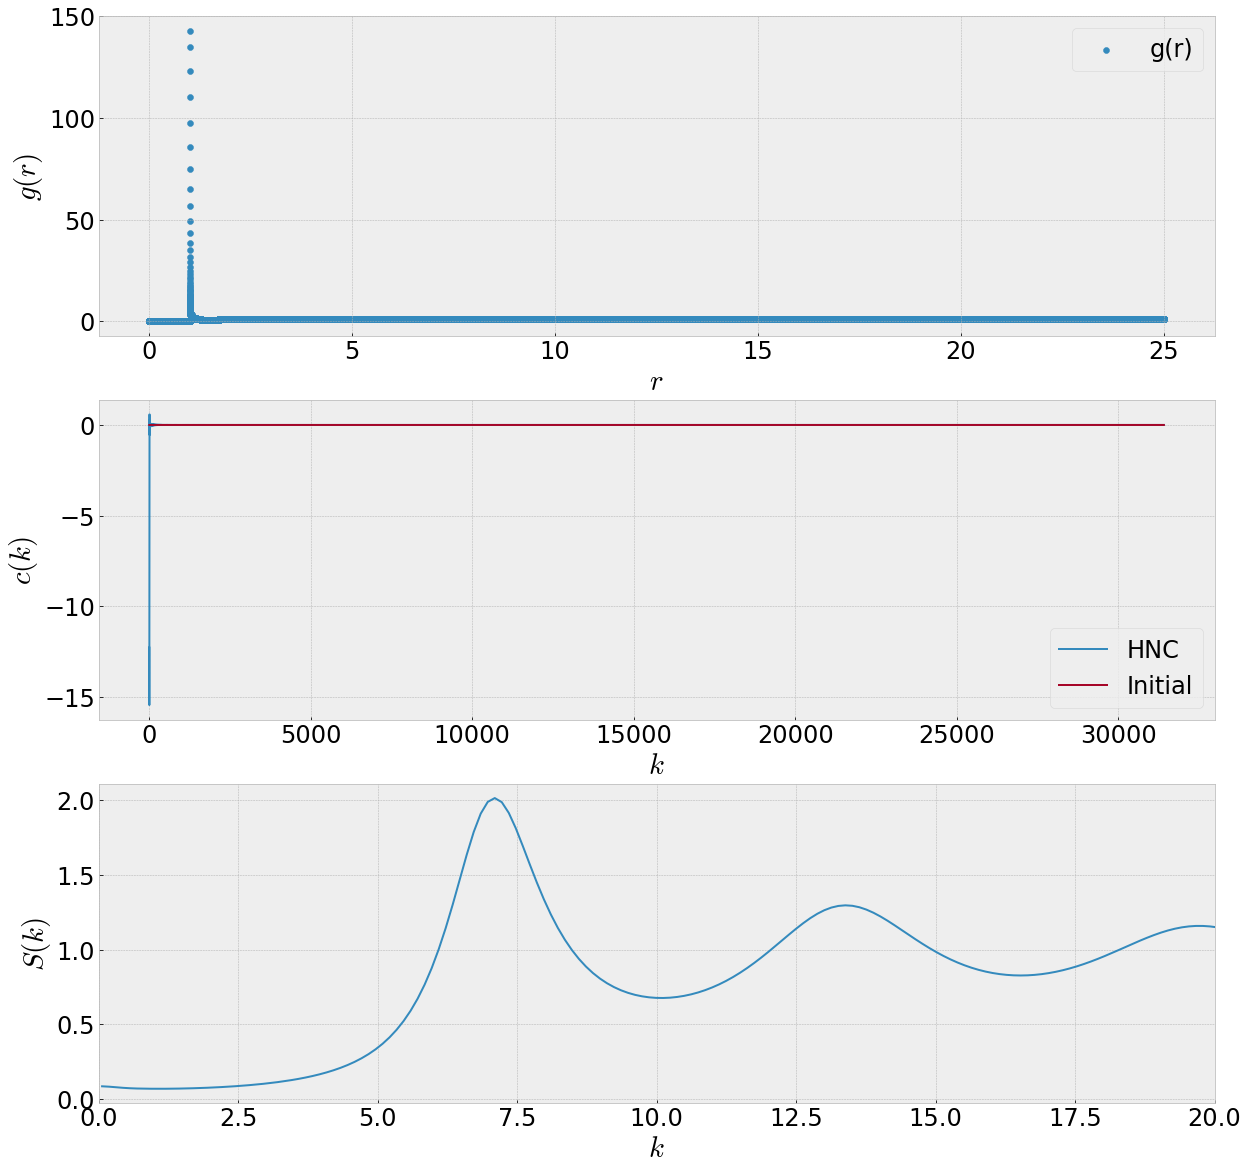

In [113]:
plt.figure(figsize=(20,20))

plt.subplot(3,1,1)
plt.scatter(r_array, g_r, label='g(r)')
plt.ylabel('$g(r)$')
plt.xlabel('$r$')
#plt.xlim(0.5,3.)
#plt.ylim(0.95,1.3)
plt.legend()
# plt.grid()

c_k_tmp = initial_c_k(k_array)
plt.subplot(3,1,2)
plt.plot(k_array,c_k, label = 'HNC')
plt.plot(k_array,c_k_tmp, label = 'Initial')
plt.ylabel('$c(k)$')
plt.xlabel('$k$')
#plt.xlim(0,20)
plt.legend()

S_k = 1+dimless_dens*c_k/(1-dimless_dens*c_k)
plt.subplot(3,1,3)
plt.plot(k_array,S_k, label = 'PY')
plt.ylabel('$S(k)$')
plt.xlabel('$k$')
plt.xlim(0,20)

## Check Convergence

* final pressure =  258.19392401868356
* peak of g(r) =  142.8855133437131


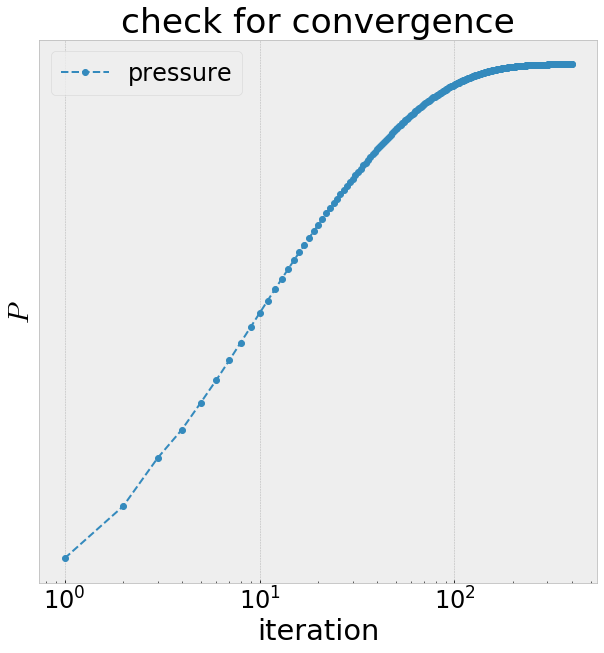

In [114]:
plt.figure(figsize=(10,10))

plt.plot(np.arange(num_iterations)+1, pressure_iter, 'o--', label='pressure')
plt.yscale('symlog')
plt.xscale('log')
plt.ylabel('$P$')
plt.xlabel('iteration')
plt.title("check for convergence")
plt.legend()

print('* final pressure = ',pressure_iter[len(pressure_iter)-1])
print('* peak of g(r) = ',np.max(g_r))
#print('* peak of S(k) = ',np.max(S_k))

## Save data

In [115]:
#DCF
c_data = np.array([k_array,c_k]).T
np.savetxt('c_k.in',c_data)
#PCF
g_data = np.array([r_array,g_r]).T
np.savetxt('g_r_Pe1000_eta0p45.in',g_data)
#Static structure facto
#S_k = 1 + dimless_dens * c_k / ( 1 - dimless_dens * c_k ) 
#S_data = np.array([k_array,S_k]).T
# np.savetxt('S_HS_0p30.in',S_data)